===================data cleaning============================

Import library of python

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Read data from csv file 

In [167]:
data=pd.read_csv("UberDataset.csv")

show 1st 5 row from datasent

In [168]:
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [169]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


here we find some point 

1. start date and end date is an object which is wrong while both column are date time data type
2. purpose column have many null data present

so now we need data preprocessing 

find data shape(row,column)

In [170]:
data.shape

(1156, 7)

basic stastics

In [171]:
data.describe()

,MILES
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


================data pre processing=============================

in purpose column we have nan value present we want to replace data with note 

find count of nan value

In [172]:
data['PURPOSE'].isna().sum()

np.int64(503)

replace data nan to note

In [227]:
data['PURPOSE'].fillna('not', inplace=True)

C:\Users\an096\AppData\Local\Temp\ipykernel_32300\3691704628.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['PURPOSE'].fillna('not', inplace=True)


print first 5 row

In [228]:
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,s_date,s_time,time_category,S_Month,S_Day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,night,January,Friday
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,not,2016-01-02,1,morning,January,Saturday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,night,January,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,evening,January,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,afternoon,January,Wednesday


change start date and end date datatype object to datetime

In [229]:
data['START_DATE']=pd.to_datetime(data['START_DATE'],errors='coerce')
data['END_DATE']=pd.to_datetime(data['END_DATE'],errors='coerce')
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 413 entries, 0 to 1047
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   START_DATE     413 non-null    datetime64[ns]
 1   END_DATE       413 non-null    datetime64[ns]
 2   CATEGORY       413 non-null    object        
 3   START          413 non-null    object        
 4   STOP           413 non-null    object        
 5   MILES          413 non-null    float64       
 6   PURPOSE        413 non-null    object        
 7   s_date         413 non-null    datetime64[ns]
 8   s_time         413 non-null    int32         
 9   time_category  413 non-null    category      
 10  S_Month        413 non-null    object        
 11  S_Day          413 non-null    object        
dtypes: category(1), datetime64[ns](3), float64(1), int32(1), object(6)
memory usage: 37.7+ KB


show data after modification

In [230]:
data.head()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,s_date,s_time,time_category,S_Month,S_Day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,night,January,Friday
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,not,2016-01-02,1,morning,January,Saturday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,night,January,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,evening,January,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,afternoon,January,Wednesday


create 2 column for date and time which is partion of start date

In [231]:
data['s_date']=data['START_DATE'].dt.date
data['s_time']=data['START_DATE'].dt.hour

show data after ad two new column

In [232]:
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,s_date,s_time,time_category,S_Month,S_Day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,night,January,Friday
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,not,2016-01-02,1,morning,January,Saturday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,night,January,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,evening,January,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,afternoon,January,Wednesday


devide category based on time 

In [233]:
data['time_category']=pd.cut(data['s_time'],bins=[0,10,15,19,24],labels=['morning','afternoon','evening','night'])

data show with new column

In [234]:
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,s_date,s_time,time_category,S_Month,S_Day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,night,January,Friday
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,not,2016-01-02,1,morning,January,Saturday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,night,January,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,evening,January,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,afternoon,January,Wednesday


drop null value from data set

In [235]:
data.dropna(inplace=True)

In [236]:
data.shape

(413, 12)

i have some question

Q1. In which category do people book the most uber rides?

Q2. for which purpose do people book uber rides the most?

Q3. At what time do people book cabs the most from uber.

Q4. in which month do people book uber rides less frequently?


Q5. on which days of the week do people book uber most?

Q6. how many miles do people usually book a cab for through uber?

=====================data visulation=====================================

Ans1. In which category do people book the most uber rides?

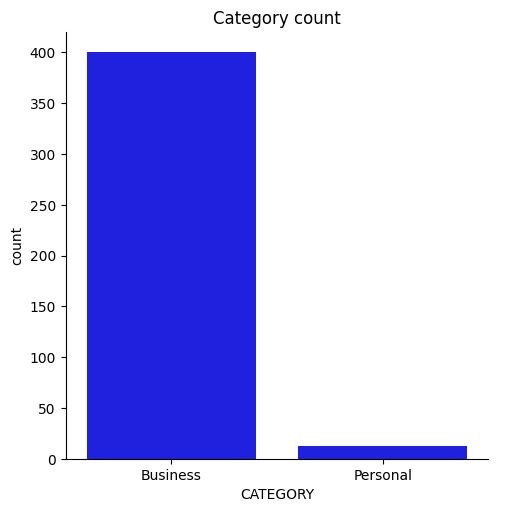

In [237]:
data['CATEGORY'].describe()
sns.catplot(x='CATEGORY',kind='count',data=data,order=data['CATEGORY'].value_counts().index,color='blue')
plt.title('Category count')
plt.show()

or

<Axes: xlabel='count', ylabel='CATEGORY'>

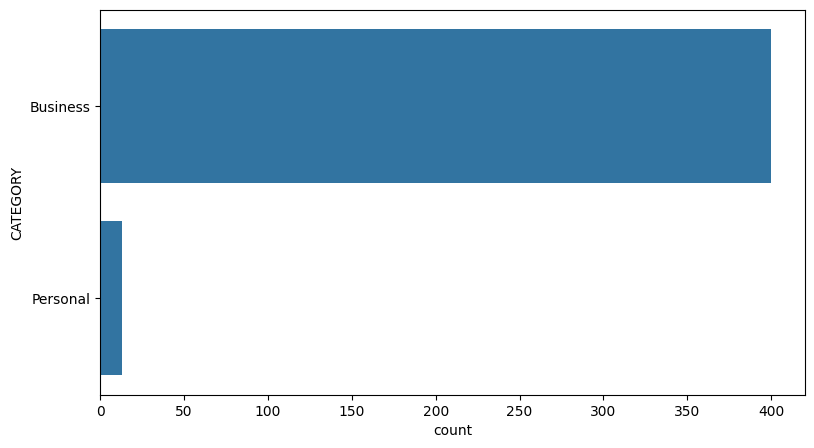

In [238]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)

sns.countplot(data['CATEGORY'])

Ans2. for which purpose do people book uber rides the most?

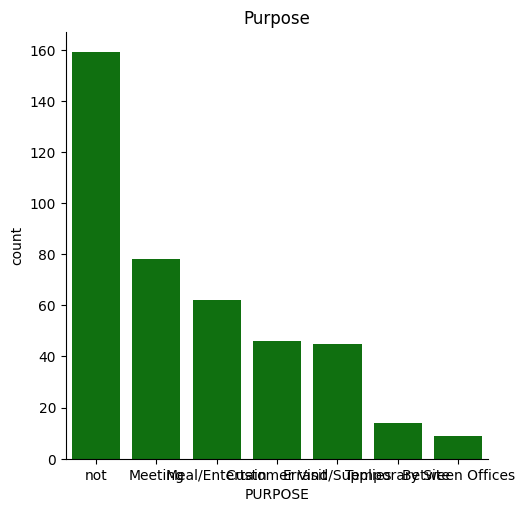

In [239]:
data['PURPOSE'].describe()
sns.catplot(x='PURPOSE',kind='count',data=data,order=data['PURPOSE'].value_counts().index,color='green')
plt.title('Purpose')
plt.show()

or 

<Axes: xlabel='count', ylabel='PURPOSE'>

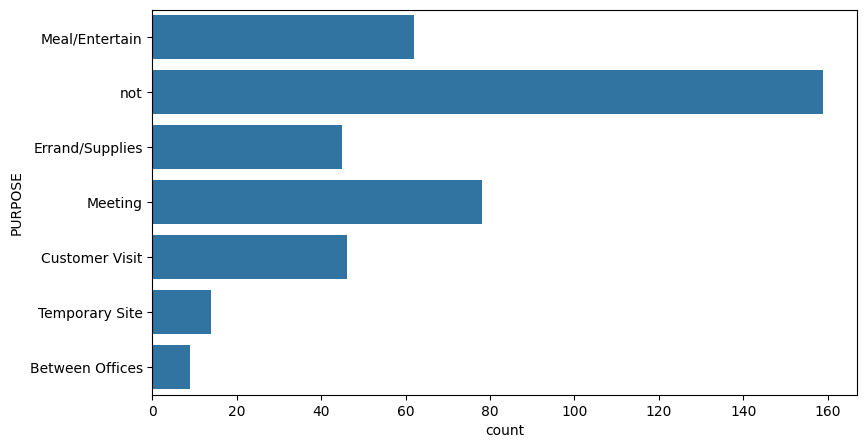

In [240]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.countplot(data['PURPOSE'])

Ans3. At what time do people book cabs the most from uber.

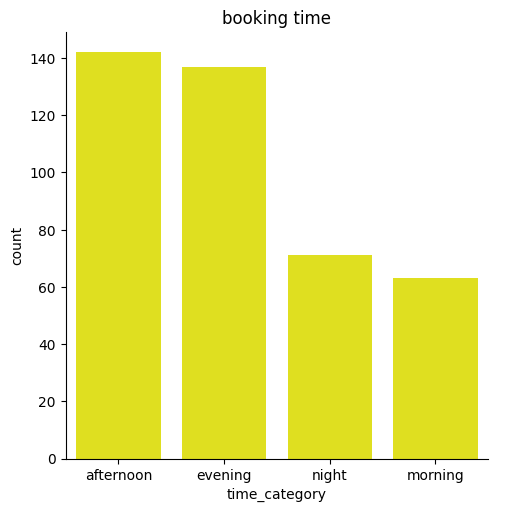

In [241]:
data['time_category'].describe()
sns.catplot(x='time_category',data=data,kind='count',order=data['time_category'].value_counts().index,color='yellow')
plt.title('booking time')
plt.show()

or

<Axes: xlabel='count', ylabel='time_category'>

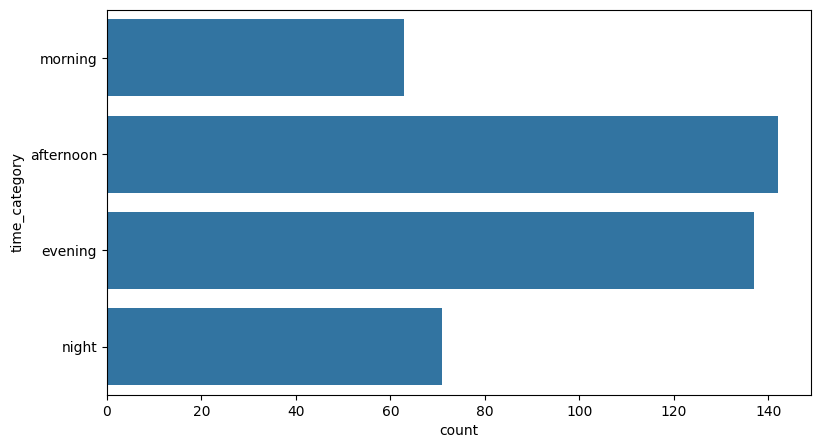

In [242]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.countplot(data['time_category'])

Ans4. in which month do people book uber rides less frequently?

change s_date data type category to date time

In [243]:
data['s_date']=pd.to_datetime(data['s_date'],errors='coerce')

check after modification

In [244]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 413 entries, 0 to 1047
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   START_DATE     413 non-null    datetime64[ns]
 1   END_DATE       413 non-null    datetime64[ns]
 2   CATEGORY       413 non-null    object        
 3   START          413 non-null    object        
 4   STOP           413 non-null    object        
 5   MILES          413 non-null    float64       
 6   PURPOSE        413 non-null    object        
 7   s_date         413 non-null    datetime64[ns]
 8   s_time         413 non-null    int32         
 9   time_category  413 non-null    category      
 10  S_Month        413 non-null    object        
 11  S_Day          413 non-null    object        
dtypes: category(1), datetime64[ns](3), float64(1), int32(1), object(6)
memory usage: 37.7+ KB


create new column in datasets

In [245]:
data['S_Month']=data['s_date'].dt.month_name()
data['S_Day']=data['s_date'].dt.day_name()

show data

In [246]:
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,s_date,s_time,time_category,S_Month,S_Day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,night,January,Friday
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,not,2016-01-02,1,morning,January,Saturday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,night,January,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,evening,January,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,afternoon,January,Wednesday


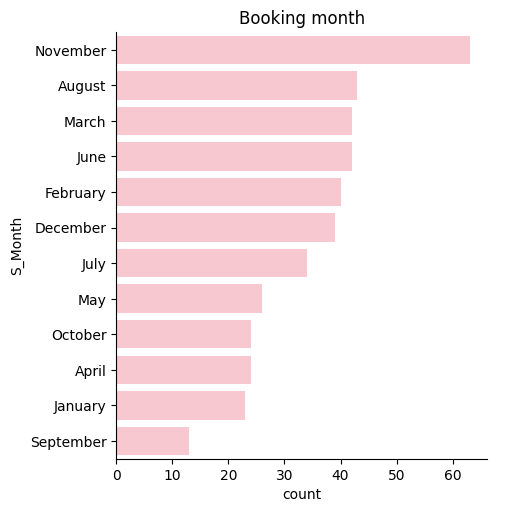

In [247]:
data['S_Month'].describe()
sns.catplot(y='S_Month',data=data,kind='count',order=data['S_Month'].value_counts().index,color='pink')
plt.title('Booking month')
plt.show()

or


<Axes: xlabel='count', ylabel='S_Month'>

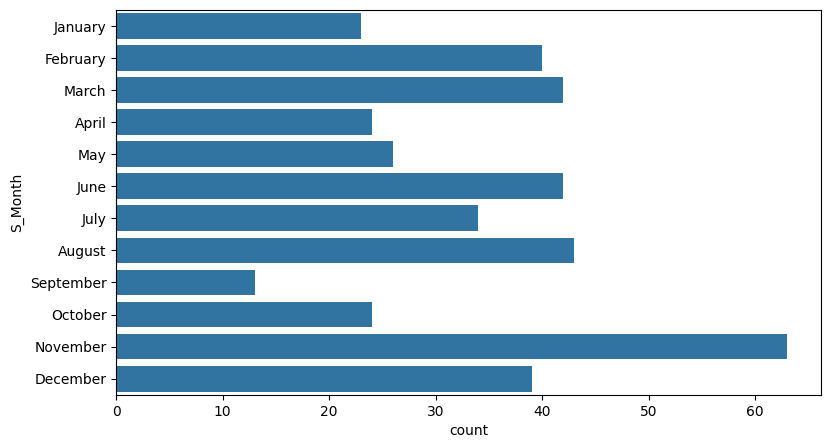

In [248]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.countplot(data['S_Month'])

Ans5. on which days of the week do people book uber most?

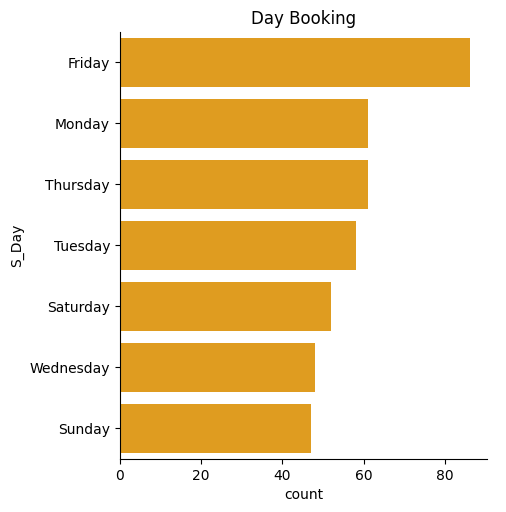

In [249]:
data['S_Day'].describe()
sns.catplot(y='S_Day',data=data,kind='count',order=data['S_Day'].value_counts().index,color='orange')
plt.title('Day Booking')
plt.show()

Ans6. how many miles do people usually book a cab for through uber?

<Axes: ylabel='MILES'>

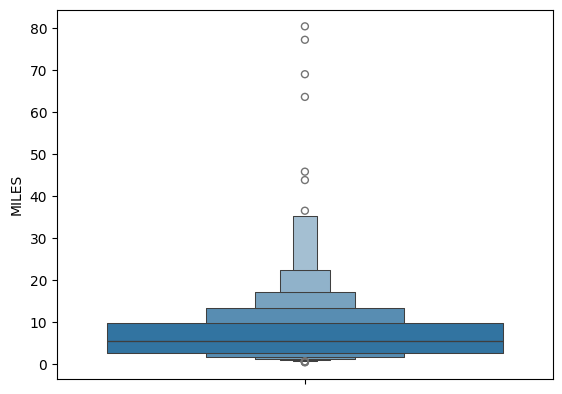

In [250]:
data['MILES'].describe()
sns.boxenplot(data[data['MILES']<100]['MILES'])


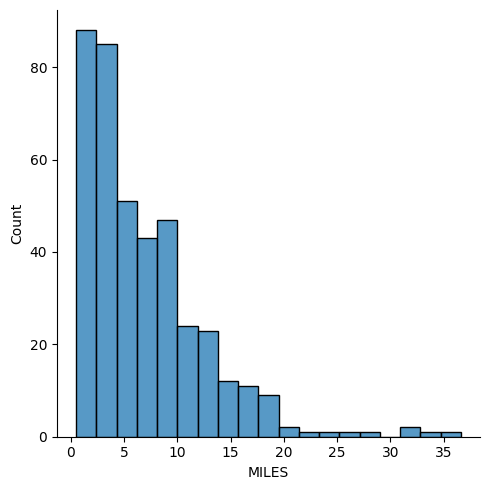

In [251]:
sns.displot(data[data['MILES']<40]['MILES'])

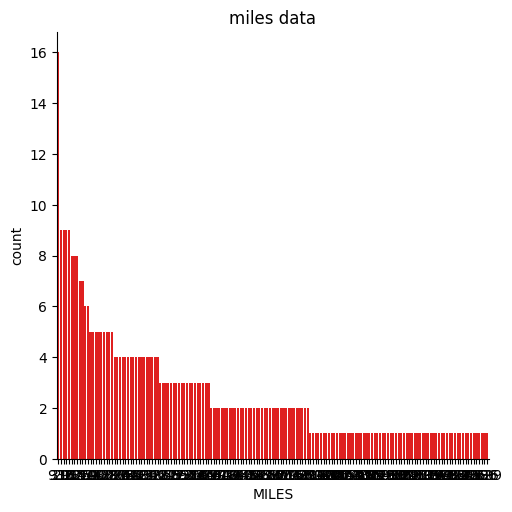

In [252]:
sns.catplot(x='MILES',data=data,kind='count',order=data['MILES'].value_counts().index,color='red')
plt.title('miles data')
plt.show()

In [253]:
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,s_date,s_time,time_category,S_Month,S_Day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,night,January,Friday
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,not,2016-01-02,1,morning,January,Saturday
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,night,January,Saturday
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,evening,January,Tuesday
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,afternoon,January,Wednesday


conclusion:

Ans1. Business category do people book the most uber rides.

Ans2. not(office),meeting purpose do people book uber rides the most.

Ans3. Afternoon time do people book cabs the most from uber.

Ans4. September month do people book uber rides less frequently.

Ans5. Friday days of the week do people book uber most.

Ans6. 0-20 miles do people usually book a cab for through uber?